In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
mali_path = "/home/mila/m/myriam.lizotte/MALI"
scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"


# save_name = f"real_batches_no_masking" #dataset}".format(dataset = dataset_name)
save_name = f"real_batches_investigation_metrics" 
# save_name = f"real_batches_no_pca_no_hvg" 
# save_name = f"real_batches_with_pca_no_hvg" 
save_path = f"{scratch_path}/results/{save_name}"


create a new summary df based on aggregating the dfs in the n_comp subfolders (only needs to be ran once)

In [19]:
batches = ["1","2","3","4","5","6", "A1", "A2", "A3", "A4", "A5", "A6", "B1", "B2", "B3", "B4"]

all_results_df = pd.DataFrame()
for i1, batch1 in enumerate(batches):
    save_path_subfolder = f"{save_path}/{batch1}"
    try:
        df = pd.read_csv(f"{save_path_subfolder}/real_batches_results.csv")
    except FileNotFoundError:
        df = pd.DataFrame()
        print(f"File not found: {save_path_subfolder}/real_batches_results.csv")

    df["batch"] = batch1
    all_results_df = pd.concat([all_results_df, df], ignore_index=True)
            
all_results_df    
all_results_df.to_csv(f"{save_path}/real_batches_results.csv", index=False)
                

In [27]:
all_results_df.batch


0      1
1      1
2      1
3      1
4      2
      ..
59    B3
60    B4
61    B4
62    B4
63    B4
Name: batch, Length: 64, dtype: object

In [20]:
all_results_df

,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,batch
0,Unintegrated,0.6944662,0.694235088610316,0.4287858427446083,0.7346043975541815,0.4900243754179149,0.5954727,1.0,0.8900765,0.7538762,0.8888888888888888,0.6334979435936158,0.0,0.6332679119600629,0.6625126530598789,0.6508147566199526,NaN,1
1,FoSTA,0.7732852,0.7263177513271203,0.4479904336636769,0.796757609564362,0.6423026774812253,0.80408597,1.0,0.74090546,0.9596547,0.8566239026667269,0.8817482176497279,0,0.6877864426484961,0.7415342360134157,0.7200351186674478,0.6755593127726034,1
2,RFMALI,0.7576684,0.7065321149594916,0.4491819362883256,0.7740775800252694,0.6009251676635937,0.8017554,1.0,0.87361395,0.96750236,0.8882978723404256,0.8756851174115908,0,0.7210198597835942,0.7271629433171175,0.7247057099037082,0.6976951748808102,1
3,Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score,Bio Conservation (label-free),1
4,Unintegrated,0.6739977,0.7163096234722268,0.41937385004113353,0.6604016915289819,0.30646234819104473,0.5501716,1.0,0.9260733,0.74591243,0.7777777777777778,0.7681598982636003,0.0,0.6435846842942741,0.6181024038772872,0.628295316044082,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score,Bio Conservation (label-free),B3
60,Unintegrated,0.5291926,0.5130566192940171,0.351867723437279,0.5193317395415503,0.33897499757479566,0.473146,0.9914883,0.91856045,0.74443054,0.6,0.42741347977241984,0.0,0.5380809053355875,0.5310082822571238,0.5338373314885093,NaN,B4
61,FoSTA,0.5569365,0.48480010604022933,0.19527213403329388,0.5863212705869096,0.5048008987989723,0.5336553,0.99793875,0.8998935,0.9630182,0.6,0.5784929908422388,0,0.6082809384089263,0.5513892785608163,0.5741459425000603,0.0,B4
62,RFMALI,0.5220269,0.41028366225684465,0.08554023596803931,0.5758094961815563,0.5004265115549328,0.5306878,0.9974295,0.91856045,0.9427979,0.5,0.45223715528219316,0,0.5627191118883478,0.5174577287882877,0.5355622820283117,0.0,B4


# Real batches data

In [28]:
# exp = "real_batches_20pct_masking"
# exp = "real_batches_no_masking"
exp=save_name
results_path = f"/home/mila/m/myriam.lizotte/scratch/RF-MALI/results/{exp}"

# load results
results_df = pd.read_csv(f"{results_path}/real_batches_results.csv")


metric_type = results_df.loc[results_df["method"] == "Metric Type"]
metric_type = metric_type.drop(columns=['method']).drop_duplicates()
results_df = results_df.loc[results_df["method"] != "Metric Type"]


# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['method', 'batch'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')


# results_df = results_df.drop(0, axis = 0) # remove one run from debugging
# results_df.drop_duplicates(subset=['method'], keep='last', inplace=True)


# delete rows where n_components is NA
# results_df = results_df.loc[~results_df["n_components"].isna()]


# remove n_components in the model column (it was just used to not overwrite adata, and it's already another column)
results_df["method"] = results_df["method"].str.replace(r'_\d+_components', '', regex=True)

In [29]:
# rename FOSTA PHATE t2 to FoSTA
results_df["method"] = results_df["method"].replace({"FoSTA_PHATE_t2": "FoSTA"})
results_df["method"] = results_df["method"].replace({"RFMALI_PHATE_t2": "RFMALI"})

# methods_to_remove= ["RFMALI", "LIGER"]
# results_df = results_df[~results_df["method"].isin(methods_to_remove)]

In [ ]:
# results_df["Bio conservation"]
results_df.columns

Index(['method', 'Isolated labels', 'Leiden NMI', 'Leiden ARI', 'KMeans NMI',
       'KMeans ARI', 'Silhouette label', 'cLISI', 'BRAS', 'iLISI', 'KBET',
       'Graph connectivity', 'PCR comparison', 'Batch correction',
       'Bio conservation', 'Total', 'cell_cycle_score', 'batch1'],
      dtype='object')

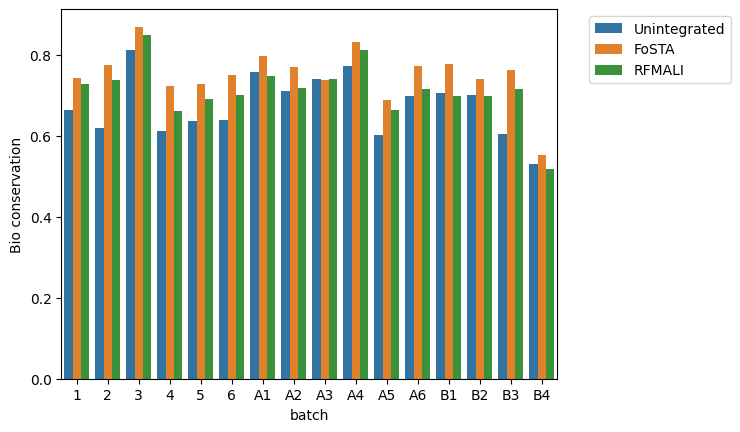

In [34]:
sns.barplot(data=results_df, x="batch", y="Bio conservation", hue="method")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

<Axes: xlabel='batch', ylabel='cell_cycle_score'>

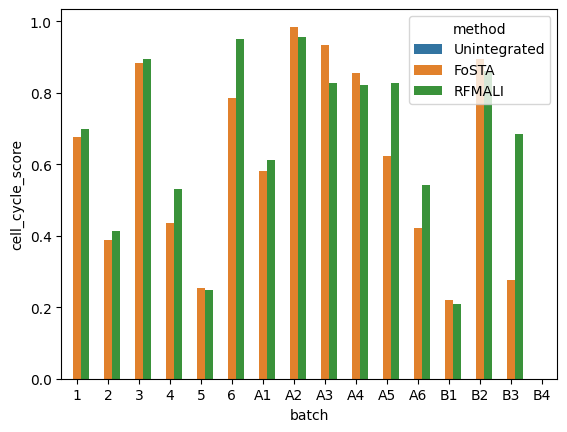

In [32]:
sns.barplot(data=results_df, x="batch", y="cell_cycle_score", hue="method")

# make plots

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


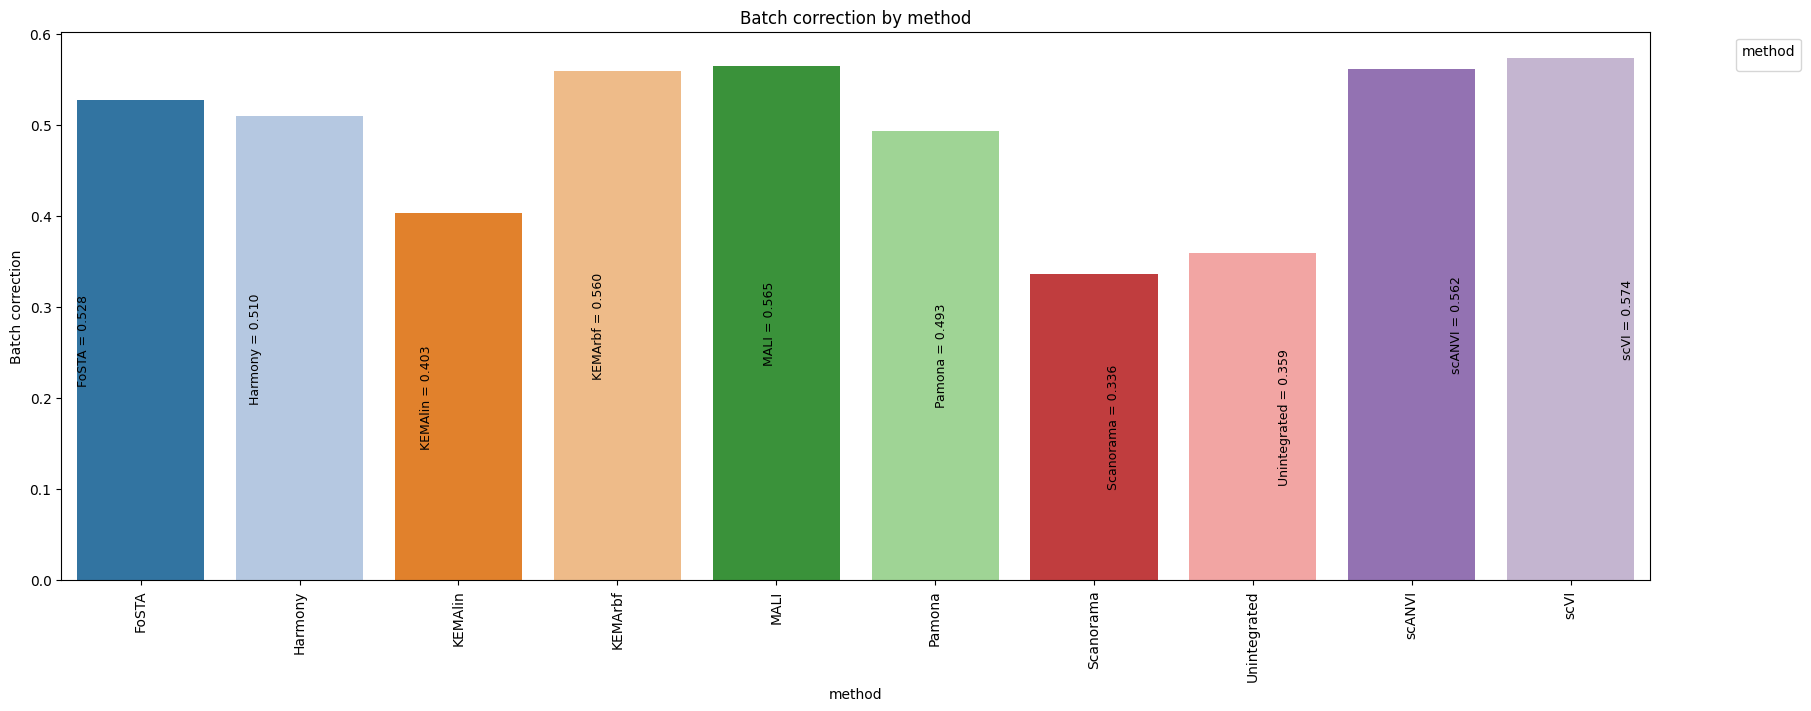

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


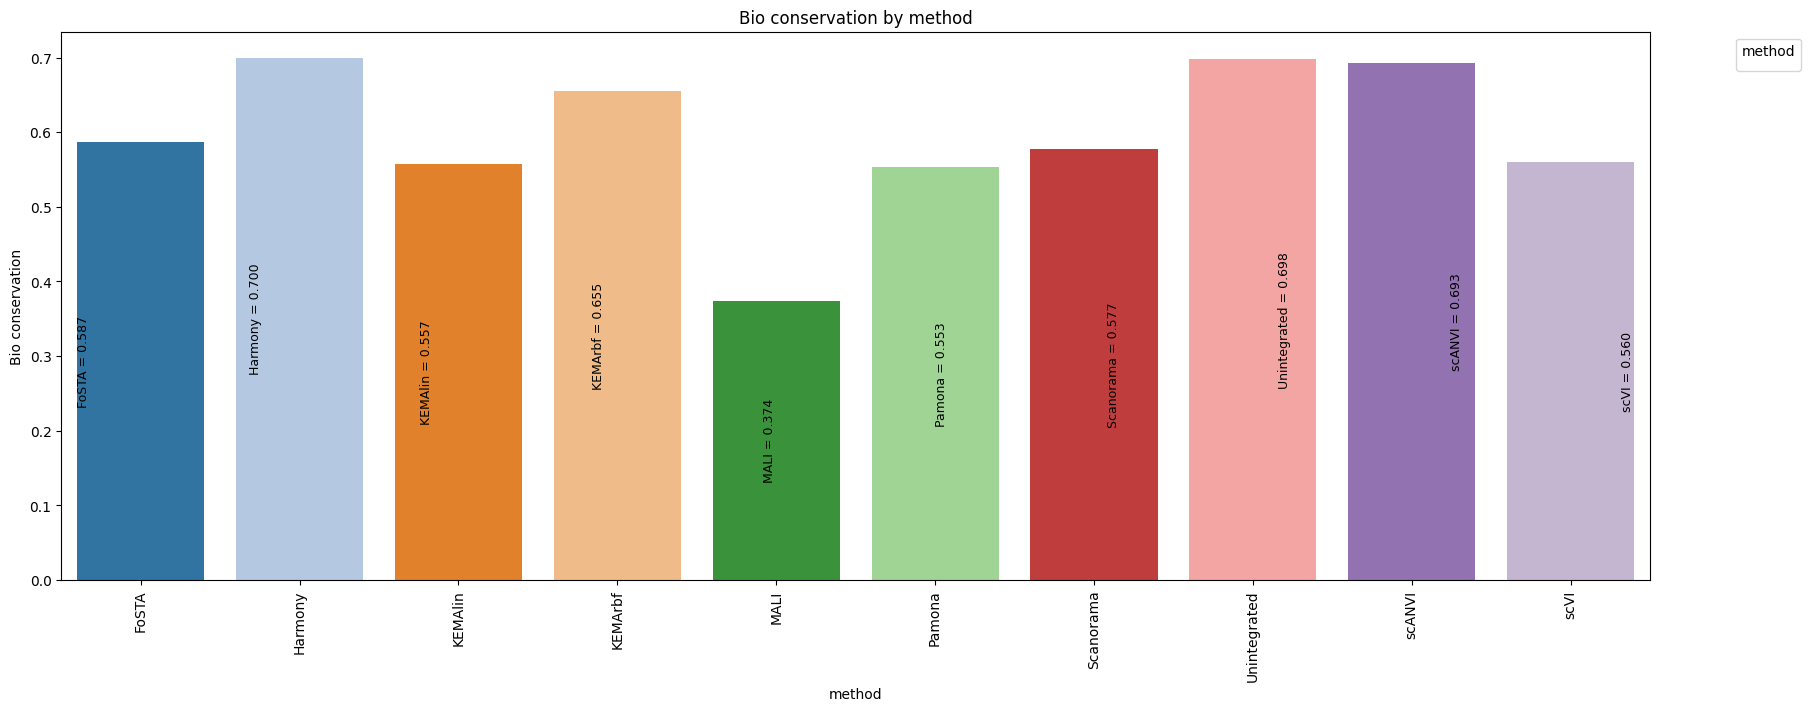

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:281: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


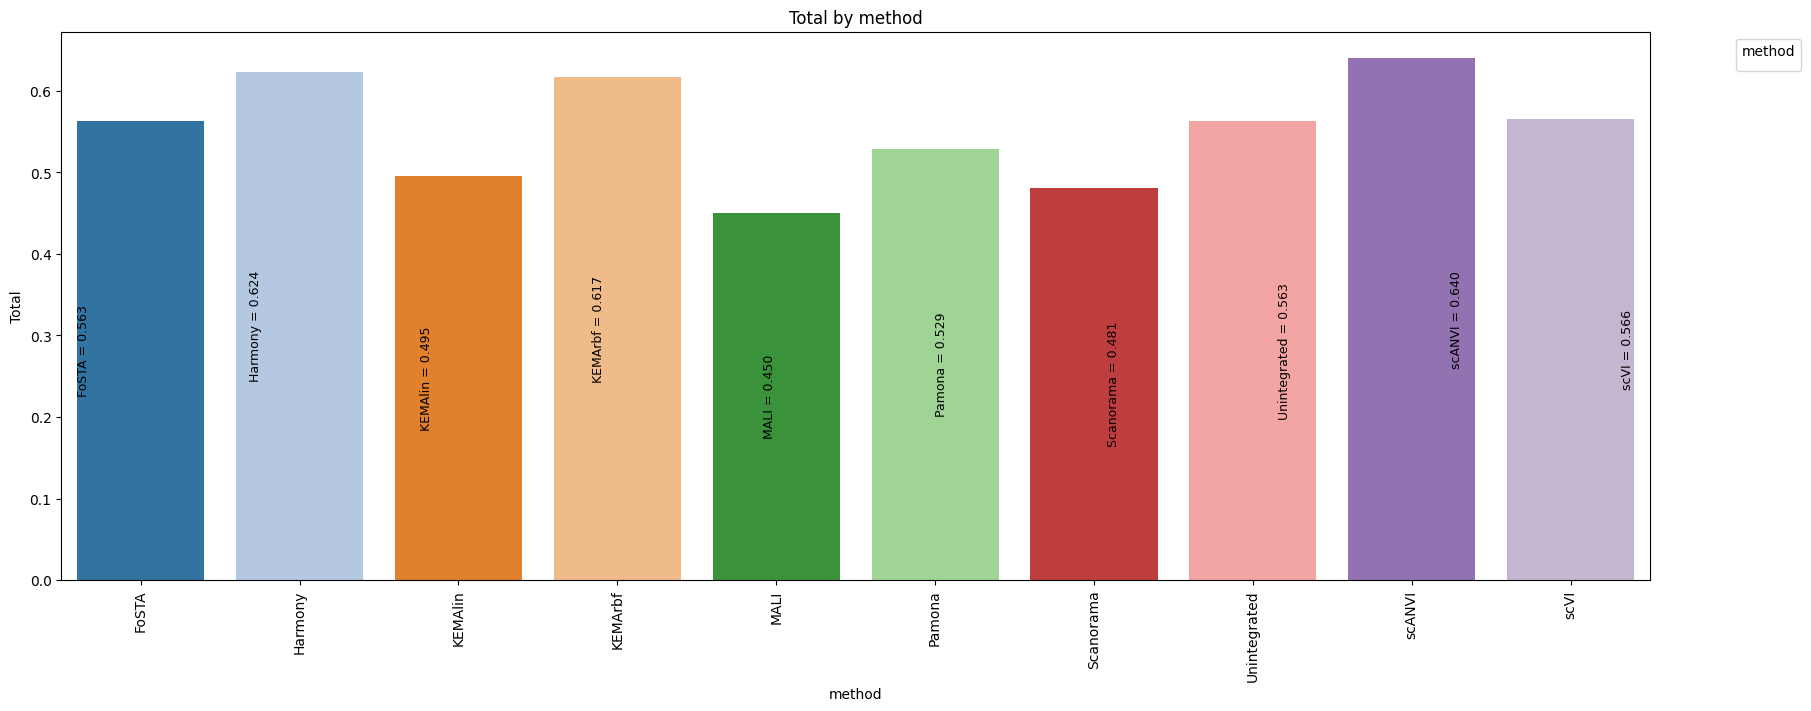

In [31]:
plot_metric_grouped_by(results_df, groupby_cols=["method"])

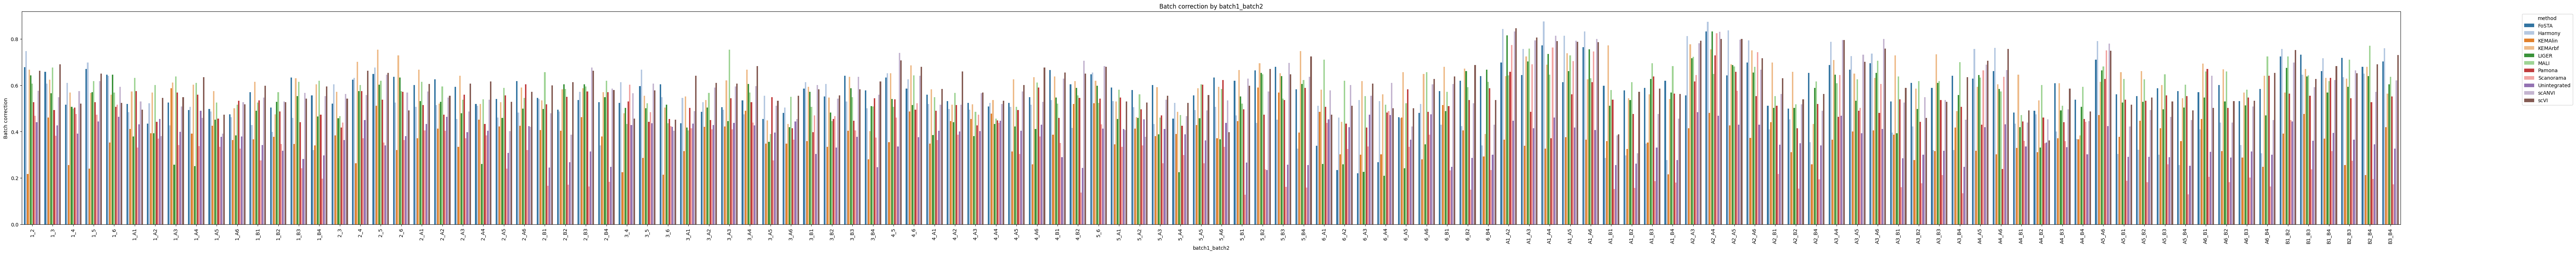

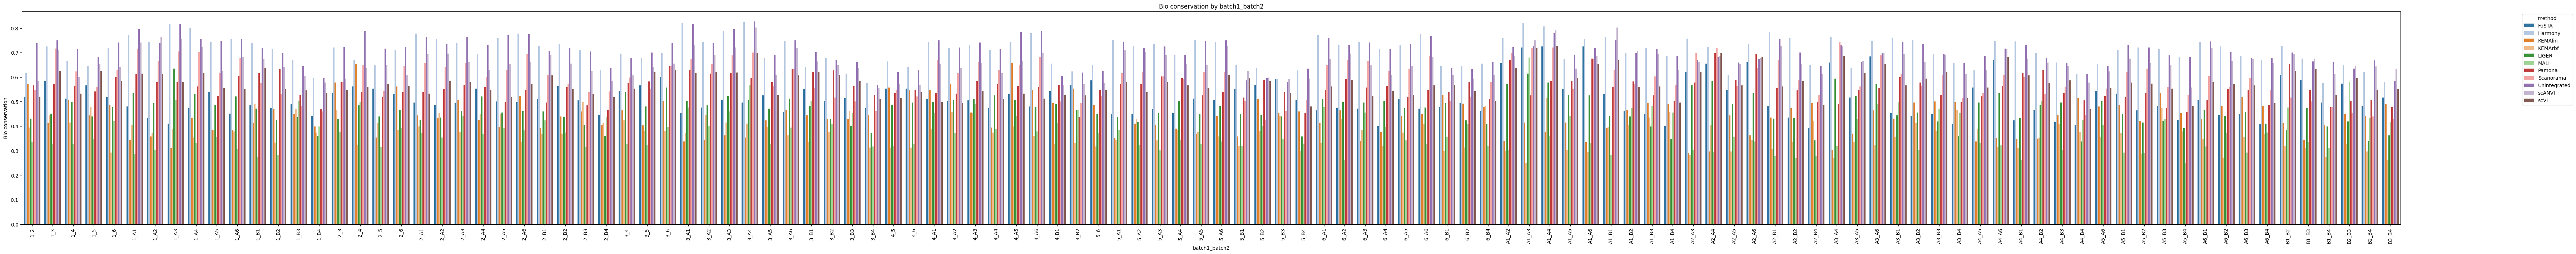

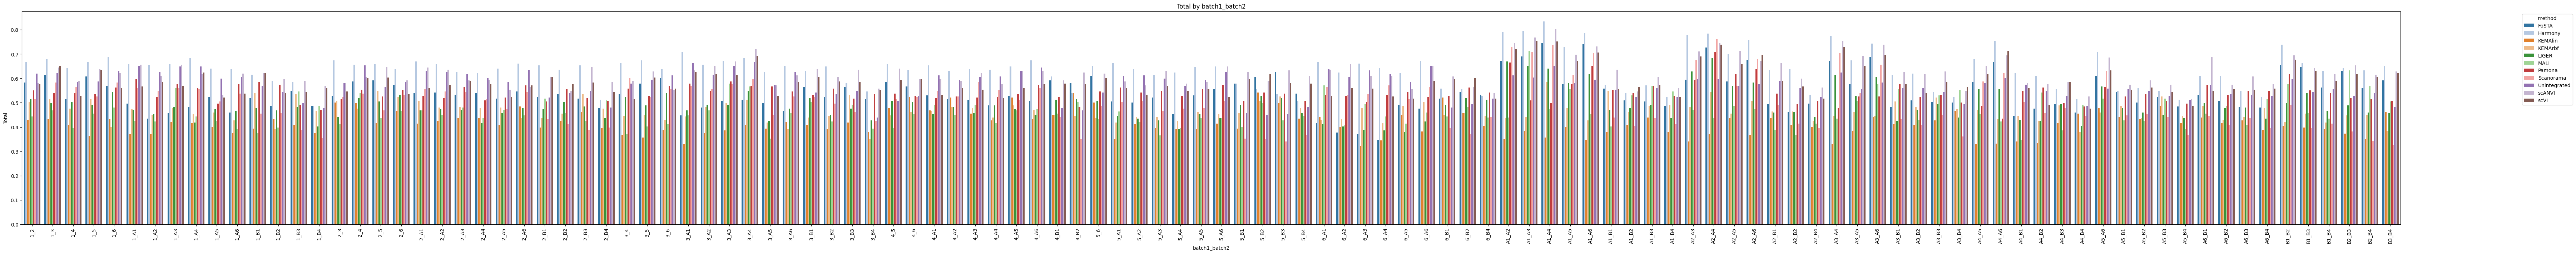

In [12]:
plot_metric_grouped_by(results_df, groupby_cols=["batch1_batch2", "method"], annotate=False, fig_len_factor=4)

In [39]:
results_df["batch1_batch2"] = results_df["batch1"] + "_" + results_df["batch2"]

In [40]:
len(results_df["batch1_batch2"].unique())

120

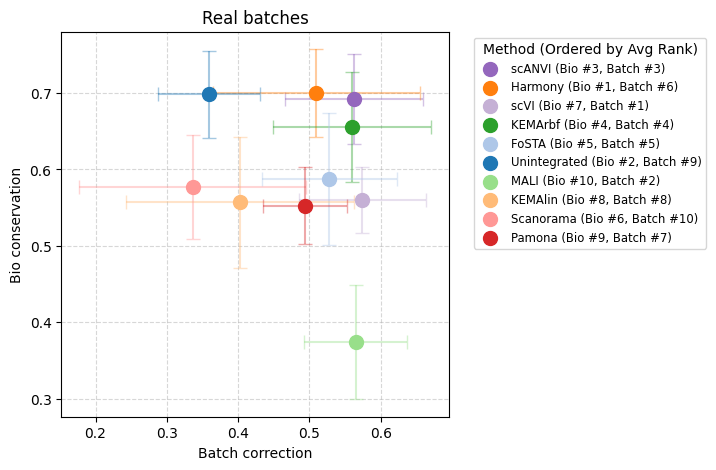

In [32]:
plot_bio_vs_batch_correction(results_df, title= "Real batches")

# look for the best performance

In [59]:
best_idx_total = results_df.loc[results_df["method"] == "FoSTA", "Total"].idxmax()
best_idx_bio = results_df.loc[results_df["method"] == "FoSTA", "Bio conservation"].idxmax()
best_idx_batch = results_df.loc[results_df["method"] == "FoSTA", "Batch correction"].idxmax()

best_pair_total = results_df.loc[best_idx_total]["batch1_batch2"]
best_pair_bio = results_df.loc[best_idx_bio]["batch1_batch2"]
best_pair_batch = results_df.loc[best_idx_batch]["batch1_batch2"]

total_pair_df = results_df.loc[results_df["batch1_batch2"] == best_pair_total]
bio_pair_df = results_df.loc[results_df["batch1_batch2"] == best_pair_bio]
batch_pair_df = results_df.loc[results_df["batch1_batch2"] == best_pair_batch]

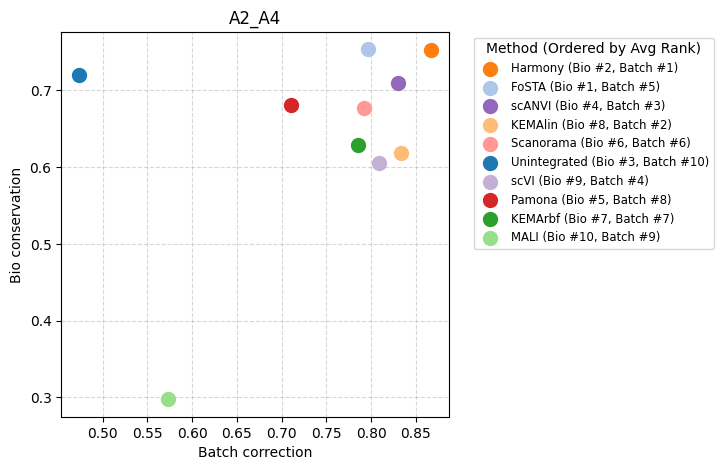

In [65]:
plot_bio_vs_batch_correction(total_pair_df, title = best_pair_total)

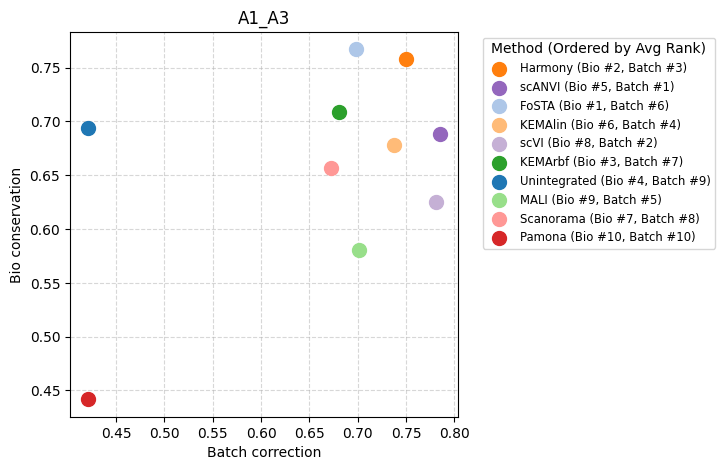

In [66]:
plot_bio_vs_batch_correction(bio_pair_df, title = best_pair_bio)

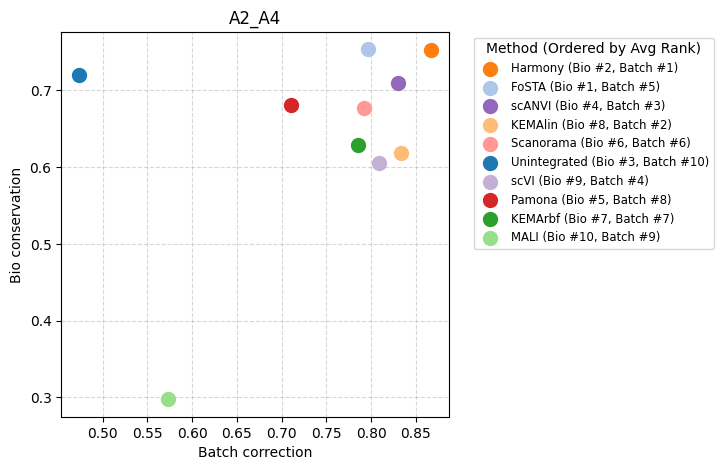

In [67]:
plot_bio_vs_batch_correction(batch_pair_df, title = best_pair_batch)

# only consider batches within the same set

In [17]:
results_df["batch1"] = results_df["batch1"].astype(str)
results_df["batch2"] = results_df["batch2"].astype(str)

In [18]:
def get_set_of_batch(batch):
    if batch.startswith("A"):
        return "A"
    elif batch.startswith("B"):
        return "B"
    else:
        return "0"
    
results_df["same_batch_set"] = (results_df["batch1"].apply(get_set_of_batch) == results_df["batch2"].apply(get_set_of_batch))

In [19]:
same_batch_results_df = results_df.loc[results_df["same_batch_set"] == True]

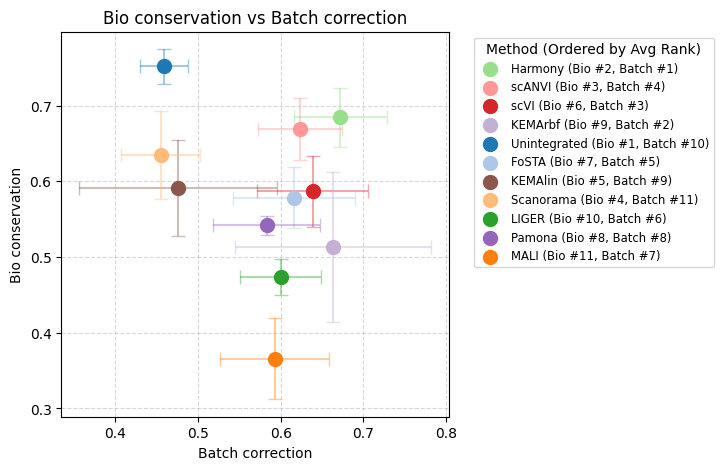

In [20]:
plot_bio_vs_batch_correction(same_batch_results_df)